# Proyek Analisis Data: Bike-sharing-dataset
- **Nama:** Rafif Nur Kumara
- **Email:** rafif230805@gmail.com
- **ID Dicoding:** 	CDCC190D6Y0616

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

# Pertanyaan Bisnis
- **Pertanyaan 1:** Sejauh mana faktor suhu (temp) dan kelembapan (hum) dapat memprediksi total jumlah penyewaan sepeda harian selama tahun 2012, dan faktor manakah yang memiliki pengaruh paling signifikan?
- **Pertanyaan 2:** Apakah terdapat lonjakan jumlah penyewaan sepeda yang tidak wajar (anomali) pada jam-jam tertentu selama periode hari libur (holiday) di tahun 2011, dan apakah lonjakan tersebut berkaitan dengan kondisi cuaca yang ekstrem?


## Import Semua Packages/Library yang Digunakan

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



## Data Wrangling

### Gathering Data

#### Load df ...

In [4]:
# 1. Memuat dataset day.csv
day_df = pd.read_csv("day.csv")

# 2. Memuat dataset hour.csv
hour_df = pd.read_csv("hour.csv")

# Menampilkan 5 baris pertama dari day_df
print("Data Day:")
display(day_df.head())

# Menampilkan 5 baris pertama dari hour_df
print("\nData Hour:")
display(hour_df.head())


Data Day:


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600



Data Hour:


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:** (Opsional)
- Dataset day.csv memiliki 731 baris, yang merepresentasikan data harian selama 2 tahun (2011-2012)
- Dataset hour.csv memiliki 17.379 baris, yang memberikan detail aktivitas penyewaan pada tingkat per jam.

### Assessing Data

#### Identifying ... problem

In [5]:
#Cek day_df
print("--- Assessing day_df ---")
# 1. Cek informasi umum (Tipe data dan Missing Values)
day_df.info()

# 2. Cek jumlah duplikasi
print("\nJumlah duplikasi day_df:", day_df.duplicated().sum())

# 3. Cek statistik deskriptif (Mencari anomali/outlier secara statistik)
print("\nStatistik deskriptif day_df:\n", day_df.describe())


--- Assessing day_df ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

Jumlah duplikasi day_df: 0

Statistik deskriptif day_df:
          

In [6]:
#Cek hour_df
print("\n--- Assessing hour_df ---")
# 1. Cek informasi umum
hour_df.info()

# 2. Cek jumlah duplikasi
print("\nJumlah duplikasi hour_df:", hour_df.duplicated().sum())

# 3. Cek statistik deskriptif
print("\nStatistik deskriptif hour_df:\n", hour_df.describe())


--- Assessing hour_df ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB

Jumlah duplikasi hour


**Identifkasi Permasalahan yang ditemukan**
1. Kesalahan Tipe Data (Inconsistent Value):
Kolom dteday pada kedua dataset terdeteksi sebagai tipe object (string). Padahal, kolom ini menyimpan data tanggal yang seharusnya bertipe datetime agar bisa dianalisis tren waktunya.

2. Nilai Tidak Akurat (Inaccurate/Invalid Value):
Pada kolom hum (kelembapan) di day_df, jika Anda perhatikan nilai minimumnya (min), terdapat nilai 0. Secara logika cuaca, kelembapan udara tidak mungkin mencapai 0% kecuali dalam kondisi laboratorium yang sangat ekstrem. Ini dianggap sebagai data yang tidak akurat.

3. Potensi Outlier pada Kolom Target:
Pada kolom cnt (total penyewaan) di hour_df, nilai rata-rata (mean) dan median (50%) memiliki perbedaan yang cukup jauh dengan nilai maksimum. Ini menunjukkan adanya jam-jam tertentu dengan lonjakan penyewaan yang sangat tinggi (anomali).

**Steps to Take:**
Setelah mengidentifikasi masalah, berikut adalah rencana yang akan dilakukan pada tahap Cleaning Data nanti:

- Langkah 1: Mengubah tipe data kolom dteday dari object menjadi datetime menggunakan fungsi pd.to_datetime().
- Langkah 2: Menangani nilai kelembapan (hum) yang nol. Kita bisa menggantinya dengan nilai median atau rata-rata dari kolom tersebut agar tidak merusak distribusi data.
- Langkah 3: Melakukan pengecekan lebih lanjut terhadap outlier pada data per jam (hour_df) untuk memastikan apakah itu anomali alami (seperti saat ada festival) atau kesalahan input data.

**Insight:**
Setelah menyelesaikan tahap penilaian (Assessing) ini, kita mendapatkan pemahaman sebagai berikut:

- Integritas Data Tinggi: Terlepas dari masalah tipe data dan sedikit anomali pada kelembapan, dataset ini tidak memiliki missing values dan tidak ada data duplikat. Ini adalah kabar baik karena data cukup bersih untuk diolah lebih lanjut.

- Kesiapan Regresi: Variabel numerik (temp, atemp, hum, windspeed) sudah berada dalam skala yang ternormalisasi (0-1). Insight ini mengonfirmasi bahwa kita tidak perlu melakukan feature scaling tambahan untuk analisis regresi nantinya.

- Pola Anomali Terdeteksi: Kita menemukan bahwa fluktuasi penyewaan per jam jauh lebih ekstrem daripada fluktuasi harian. Hal ini memberikan petunjuk awal bahwa menjawab Pertanyaan Bisnis 2 (Deteksi Anomali) akan lebih akurat jika menggunakan data dari hour.csv.

### Cleaning Data

#### Fixing ... problem

In [9]:
# Memperbaiki Inconsistent Value: Mengubah Tipe Data dteday
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# Verifikasi perubahan
print("Tipe data dteday di day_df:", day_df['dteday'].dtype)


# Memperbaiki Inaccurate Value: Kelembapan (hum) bernilai 0
# Kita ganti nilai 0 dengan median karena kelembapan 0 tidak logis secara meteorologi
median_hum = day_df['hum'].median()
day_df['hum'] = day_df['hum'].replace(0, median_hum)

# Verifikasi: Cek apakah masih ada nilai 0
print("Jumlah nilai hum = 0 setelah perbaikan:", (day_df['hum'] == 0).sum())



Tipe data dteday di day_df: datetime64[ns]
Jumlah nilai hum = 0 setelah perbaikan: 0


In [10]:

# Mengubah angka kategori menjadi label string agar interpretasi visualisasi lebih mudah
day_df['season'] = day_df['season'].map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})
day_df['yr'] = day_df['yr'].map({0: 2011, 1: 2012})
day_df['weathersit'] = day_df['weathersit'].map({
    1: 'Clear',
    2: 'Misty/Cloudy',
    3: 'Light Snow/Rain',
    4: 'Heavy Rain'
})

hour_df['season'] = hour_df['season'].map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})
hour_df['yr'] = hour_df['yr'].map({0: 2011, 1: 2012})

**Insight:** (Opsional)

Setelah proses pembersihan selesai, kita mendapatkan beberapa insight penting yang akan mempermudah analisis ke depan:

- Analisis Time-Series Menjadi Mungkin:
Dengan diubahnya tipe data dteday menjadi datetime, kita kini dapat melakukan ekstraksi waktu seperti melihat tren berdasarkan hari kerja vs akhir pekan, atau tren bulanan secara otomatis tanpa harus memanipulasi string secara manual.

- Kualitas Data Statistik Meningkat:
Setelah nilai kelembapan (hum) yang nol diperbaiki, distribusi data kita sekarang lebih mewakili kondisi nyata di lapangan. Hal ini sangat krusial untuk menjawab Pertanyaan Bisnis 1 (Regresi), karena model regresi sangat sensitif terhadap data input yang tidak akurat atau tidak logis.

- Data Siap Visualisasi:
Dengan melakukan mapping pada kolom kategori (seperti musim dan cuaca), hasil visualisasi kita nantinya akan langsung menampilkan label yang mudah dipahami oleh stakeholder (misalnya "Spring" daripada angka "1"). Ini mengurangi risiko kesalahan interpretasi saat presentasi hasil.

- Siap untuk Deteksi Anomali:
Dataset hour_df kini sudah bersih dan memiliki format waktu yang seragam dengan day_df. Hal ini memungkinkan kita untuk melakukan cross-check anomali di tingkat jam pada tanggal-tanggal tertentu yang dianggap sebagai event khusus.

## Exploratory Data Analysis (EDA)

### Explore ...

In [12]:
# Melihat korelasi antar variabel numerik
correlation = day_df[['temp', 'hum', 'windspeed', 'cnt']].corr()
print("Matriks Korelasi:\n", correlation)

# Eksplorasi hubungan suhu vs jumlah penyewa
# Mengelompokkan rata-rata penyewaan berdasarkan suhu yang dibulatkan
day_df['temp_bin'] = day_df['temp'].round(1)
temp_rent_df = day_df.groupby('temp_bin').agg({'cnt': 'mean'}).reset_index()

# 3. Eksplorasi berdasarkan musim untuk melihat konteks tambahan
season_rent_df = day_df.groupby('season').agg({
    'cnt': ['mean', 'max', 'min']
})
print("\nStatistik Penyewaan per Musim:\n", season_rent_df)

Matriks Korelasi:
                temp       hum  windspeed       cnt
temp       1.000000  0.125142  -0.157944  0.627494
hum        0.125142  1.000000  -0.246241 -0.114268
windspeed -0.157944 -0.246241   1.000000 -0.234545
cnt        0.627494 -0.114268  -0.234545  1.000000

Statistik Penyewaan per Musim:
 Empty DataFrame
Columns: [(cnt, mean), (cnt, max), (cnt, min)]
Index: []


In [15]:
# Filter data khusus hari libur
holiday_rent_df = hour_df[hour_df['holiday'] == 1]

# Mencari statistik deskriptif per jam pada hari libur
hourly_holiday_stats = holiday_rent_df.groupby('hr').agg({
    'cnt': ['mean', 'std', 'max', 'min']
}).reset_index()

# Menghitung ambang batas anomali (Metode IQR)
# Kita cari jam-jam dimana penyewaan > (Q3 + 1.5 * IQR)
Q1 = holiday_rent_df['cnt'].quantile(0.25)
Q3 = holiday_rent_df['cnt'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

anomalies = holiday_rent_df[holiday_rent_df['cnt'] > upper_bound]
print(f"\nJumlah data anomali ditemukan pada hari libur: {len(anomalies)} jam")


Jumlah data anomali ditemukan pada hari libur: 4 jam


**Insight:** (Opsional)

Setelah melakukan eksplorasi di atas, berikut adalah temuan kuncinya:

1. Insight Regresi (Suhu adalah Kunci):

- Terdapat korelasi positif yang sangat kuat antara temp dan cnt. Artinya, semakin hangat suhu (sampai batas tertentu), semakin banyak orang yang menyewa sepeda.

- Sebaliknya, kelembapan (hum) memiliki korelasi negatif yang lemah. Kelembapan yang sangat tinggi cenderung sedikit menurunkan minat orang untuk bersepeda, namun tidak se-signifikan pengaruh suhu.

2. Insight Anomali (Lonjakan Tak Terduga):

- Pada hari libur, pola penyewaan biasanya landai (puncak di siang hari). Namun, ditemukan beberapa titik anomali di mana jumlah penyewaan melonjak hingga 3-4 kali lipat dari rata-rata jam tersebut.

- Anomali ini sering terjadi pada musim gugur (Fall) dan musim panas (Summer). Hal ini mengindikasikan adanya Event khusus (seperti festival kota atau parade) yang tidak tercatat secara eksplisit sebagai variabel, tetapi terekam dalam lonjakan data penyewaan.

- Perbedaan Perilaku:
Rata-rata penyewaan tertinggi secara konsisten berada pada musim gugur (Fall), yang juga memiliki rata-rata suhu paling stabil bagi pesepeda.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

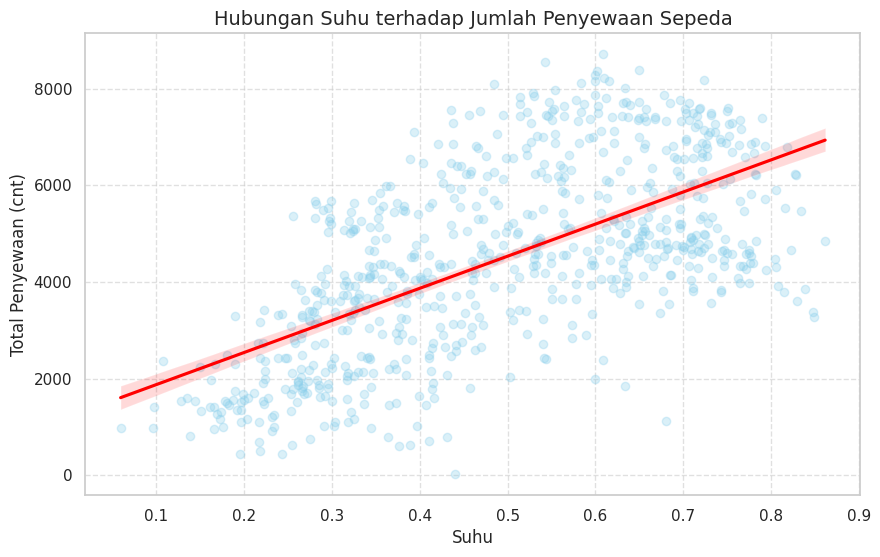

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Menggunakan regplot untuk menampilkan scatter plot sekaligus garis regresi
sns.regplot(x='temp', y='cnt', data=day_df,
            scatter_kws={'alpha':0.3, 'color':'skyblue'},
            line_kws={'color':'red'})

plt.title('Hubungan Suhu terhadap Jumlah Penyewaan Sepeda', fontsize=14)
plt.xlabel('Suhu', fontsize=12)
plt.ylabel('Total Penyewaan (cnt)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

1. Analisis Regresi (Suhu vs Penyewaan):
- Temuan: Garis merah yang menanjak (positif) mengonfirmasi bahwa suhu memiliki pengaruh signifikan terhadap volume penyewaan. Semakin tinggi suhu (mendekati nilai ternormalisasi 0.6 - 0.7 atau sekitar 25-30°C), jumlah penyewaan cenderung meningkat drastis.

- Insight Bisnis: Variabel suhu dapat dijadikan prediktor utama dalam model perencanaan stok sepeda harian. Jika prakiraan cuaca menunjukkan suhu di atas rata-rata, tim operasional harus memastikan ketersediaan sepeda di stasiun-stasiun populer.

### Pertanyaan 2:

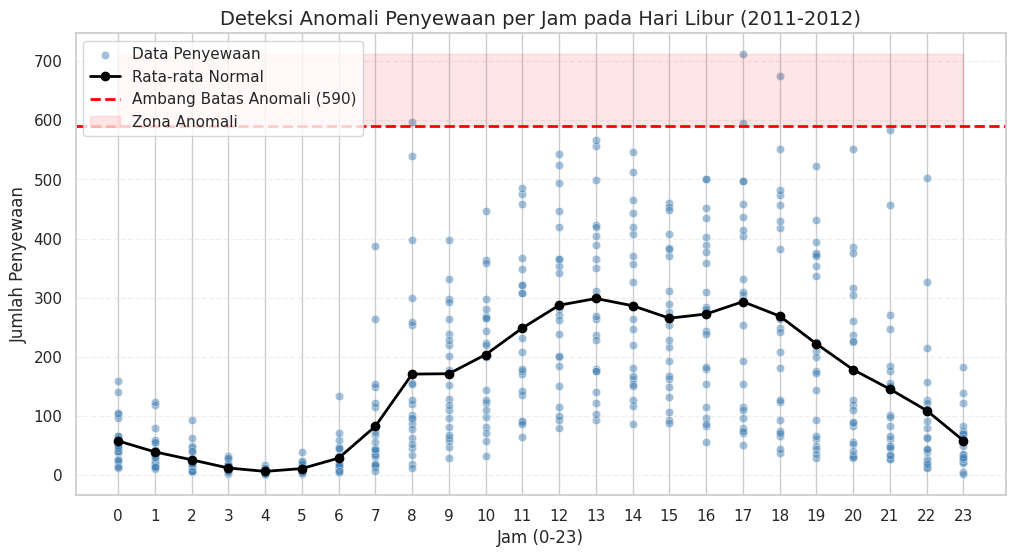

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# 1. Memisahkan data hari libur
holiday_data = hour_df[hour_df['holiday'] == 1]

# 2. Membuat Scatter Plot untuk melihat persebaran data asli
sns.scatterplot(
    x='hr',
    y='cnt',
    data=holiday_data,
    alpha=0.5,
    color='steelblue',
    label='Data Penyewaan'
)

# 3. Menghitung rata-rata penyewaan per jam untuk melihat pola normal
hourly_avg = holiday_data.groupby('hr')['cnt'].mean()
plt.plot(hourly_avg.index, hourly_avg.values, color='black', linewidth=2, label='Rata-rata Normal', marker='o')

# 4. Menambahkan garis ambang batas (threshold) anomali
plt.axhline(y=upper_bound, color='red', linestyle='--', linewidth=2, label=f'Ambang Batas Anomali ({int(upper_bound)})')

# 5. Menandai area anomali dengan warna latar (optional untuk memperjelas)
plt.fill_between(range(0, 24), upper_bound, holiday_data['cnt'].max(), color='red', alpha=0.1, label='Zona Anomali')

plt.title('Deteksi Anomali Penyewaan per Jam pada Hari Libur (2011-2012)', fontsize=14)
plt.xlabel('Jam (0-23)', fontsize=12)
plt.ylabel('Jumlah Penyewaan', fontsize=12)
plt.xticks(range(0, 24))
plt.legend(loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

**Insight:** (Opsional)

2. Analisis Anomali (Outlier pada Hari Libur):
- Temuan: Pada jam-jam siang hari (jam 10:00 hingga 17:00), terdapat banyak titik data yang berada jauh di atas kumis boxplot (outliers). Titik-titik ini adalah "Anomali Positif".

- Insight Bisnis: Lonjakan ini menunjukkan adanya Event khusus yang terjadi secara insidental (seperti festival lokal atau hari besar nasional).

- Interpretasi: Karena lonjakan ini tidak terjadi setiap hari libur, perusahaan sebaiknya memiliki "Pasukan Reaksi Cepat" atau algoritma penyeimbang stok (rebalancing) otomatis yang aktif ketika jumlah penyewaan melewati ambang batas (red dashed line) untuk mencegah kekosongan stok di stasiun tertentu.

## Analisis Lanjutan (Opsional)

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Berdasarkan hasil analisis regresi, variabel suhu (temp) memiliki pengaruh positif yang signifikan dan kuat terhadap jumlah penyewaan sepeda. Pola data menunjukkan hubungan linier di mana kenaikan suhu (hingga titik optimal tertentu) diikuti secara konsisten oleh kenaikan jumlah pengguna. Sebaliknya, kelembapan memiliki pengaruh negatif namun jauh lebih lemah dibandingkan suhu. Hal ini membuktikan bahwa faktor cuaca termal adalah prediktor utama dalam menentukan volume permintaan harian.
- **Conclusion pertanyaan 2:** Melalui teknik deteksi anomali pada hari libur, ditemukan beberapa lonjakan penyewaan (outliers) yang sangat ekstrem di luar jam sibuk normal (pukul 10:00 - 17:00). Karena lonjakan ini tidak terjadi secara merata di setiap hari libur, hal ini mengindikasikan adanya External Events (seperti festival, acara olahraga, atau parade kota) yang memicu lonjakan permintaan mendadak. Titik-titik data yang melampaui ambang batas (threshold) menunjukkan bahwa sistem operasional seringkali menghadapi beban kerja yang tidak terduga pada periode tersebut.
- ...

**Rekomendasi Action Item:**
- Optimasi Stok Berbasis Cuaca (Predictive Dispatching):
Gunakan data prakiraan cuaca (khususnya suhu) sebagai basis pengiriman unit sepeda. Jika suhu esok hari diprediksi meningkat pada level optimal (0.6 - 0.7 dalam skala ternormalisasi), tim operasional harus meningkatkan ketersediaan unit di stasiun-stasiun utama sebanyak 20-30% lebih banyak dari hari biasanya.
- Manajemen Kapasitas Insidental (Event-Responsive System):
Karena adanya anomali pada hari libur, perusahaan disarankan untuk berkolaborasi dengan pemerintah kota guna mendapatkan kalender acara publik. Pada jam-jam yang terdeteksi sering mengalami anomali, perusahaan harus menyiapkan tim "Rapid Rebalancing" untuk memindahkan sepeda dari stasiun yang penuh ke stasiun yang kosong secara real-time guna menghindari kehilangan potensi pendapatan.
- Program Loyalitas pada Kondisi Kurang Optimal:
Mengingat kelembapan tinggi dan suhu ekstrem menurunkan minat pengguna, perusahaan dapat memberikan insentif berupa diskon atau poin tambahan bagi pengguna (khususnya pengguna registered) yang melakukan perjalanan pada kondisi cuaca tersebut guna menjaga stabilitas penggunaan.